# EDA

Exploring the data.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('./data/cookie_cats.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [32]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

No misssing values. Nice.

In [33]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


Median 16 and mean 51 shows that most players quit the game by round 16. Max rounds of 50k shows bots or really obsessive players who skew the mean to 51. This skew is considered normal in gaming data. Most users are just curious for a demo.

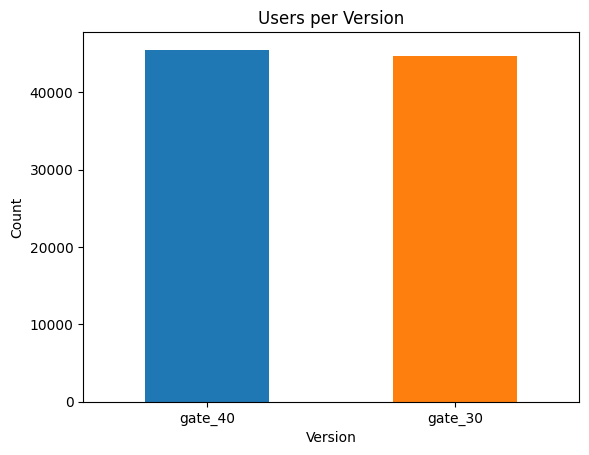

In [42]:
df['version'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Users per Version')
plt.xlabel('Version')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Statistical Tests

We test three metrics:
- **Game rounds**: Mann-Whitney U test (non-normal distribution)

    We could normalize and do T-tests instead of Mann-Whitney but this is simpler (no transformations)

- **1-day retention**: Chi-square test
- **7-day retention**: Chi-square test

In [29]:
from scipy.stats import mannwhitneyu, chi2_contingency

In [38]:
# Mann-Whitney for round distribution
_, p_value = mannwhitneyu(
    df[df.version == 'gate_30'].sum_gamerounds,
    df[df.version == 'gate_40'].sum_gamerounds
)
print(f"Rounds p-value: {p_value}")

# Chi-square for retention_1
table = pd.crosstab(df.version, df.retention_1)
chi2, p, dof, expected = chi2_contingency(table)
print(f"Retention Day 1 p-value: {p}")

# retention_7
table7 = pd.crosstab(df.version, df.retention_7)
chi2, p, dof, expected = chi2_contingency(table7)
print(f"Retention Day 7 p-value: {p:.4f}")

Rounds p-value: 0.05020880772044255
Retention Day 1 p-value: 0.07550476210309086
Retention Day 7 p-value: 0.0016


## Results

| Metric | P-value | Significant? |
|--------|---------|--------------|
| Game rounds | 0.0502 | No |
| 1-day retention | 0.0755 | No |
| 7-day retention | 0.0016 | **Yes** |

**Conclusion:** Moving the gate to level 40 did not affect early engagement but significantly improved long-term retention.